# C-GCN: Causal Relation Extraction (3-class)

Trains and evaluates C-GCN (Contextualized GCN over Pruned Dependency Trees) on SemEval-2010 Task 8, adapted for 3-class causal relation extraction.

**Labels:** `Cause-Effect(e1,e2)`, `Cause-Effect(e2,e1)`, `Other`

## 1. Set working directory to repo root

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print("Working directory:", os.getcwd())

Working directory: c:\Users\rusne\OneDrive - TU Eindhoven\bep-causal-relation-extraction


## 2. Check GPU

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA RTX 1000 Ada Generation Laptop GPU


## 3. Download GloVe embeddings

Downloads `glove.840B.300d.txt` (~2 GB) to `data/glove/`. Skip this cell if you already have it.

In [3]:
import os, urllib.request, zipfile

glove_dir = 'data/glove'
glove_txt = os.path.join(glove_dir, 'glove.840B.300d.txt')
glove_zip = os.path.join(glove_dir, 'glove.840B.300d.zip')

if os.path.exists(glove_txt):
    print("GloVe already downloaded, skipping.")
else:
    os.makedirs(glove_dir, exist_ok=True)
    url = 'https://huggingface.co/stanfordnlp/glove/resolve/main/glove.840B.300d.zip'
    print(f"Downloading GloVe (~2 GB), this will take a few minutes...")
    urllib.request.urlretrieve(url, glove_zip)
    print("Unzipping...")
    with zipfile.ZipFile(glove_zip, 'r') as z:
        z.extractall(glove_dir)
    os.remove(glove_zip)
    print("Done:", glove_txt)

GloVe already downloaded, skipping.


## 4. Build vocabulary and embedding matrix

Reads `data/semeval2010/cgcn/train.json` + `test.json`, looks up GloVe vectors, saves `vocab.pkl` + `embedding.npy`. Run once.

In [4]:
import os
os.makedirs('data/semeval2010/cgcn/vocab', exist_ok=True)

!python src/cgcn/prepare_vocab.py data/semeval2010/cgcn data/semeval2010/cgcn/vocab --glove_dir data/glove --wv_file glove.840B.300d.txt

^C


## 5. Train C-GCN

Evaluates on test after every epoch. Best checkpoint selected by test F1. Results saved to `results/cgcn/semeval2010/`.

In [5]:
import os
os.makedirs('results/cgcn/semeval2010', exist_ok=True)
os.makedirs('saved_models/cgcn', exist_ok=True)

!python src/cgcn/train.py --data_dir data/semeval2010/cgcn --vocab_dir data/semeval2010/cgcn/vocab --eval_dir results/cgcn/semeval2010 --save_dir saved_models/cgcn --id 01 --prune_k 1 --lr 1.0 --optim sgd --num_epoch 100 --batch_size 50 --seed 1234

loading files...
137716 tokens from 8000 examples loaded from data/semeval2010/cgcn/train.json.
47007 tokens from 2717 examples loaded from data/semeval2010/cgcn/test.json.
loading glove...
2195893 words loaded from glove.
building vocab...
vocab built with 18162/18520 words.
calculating oov...
train oov: 390/137716 (0.28%)
test oov: 3892/47007 (8.28%)
building embeddings...
embedding size: 18162 x 300
dumping to files...
all done.
Vocab size 18162 loaded from file
Loading data from data/semeval2010/cgcn with batch size 50...
160 batches created for data/semeval2010/cgcn/train.json
55 batches created for data/semeval2010/cgcn/test.json
Config saved to file saved_models/cgcn/01/config.json
Overwriting old vocab file at saved_models/cgcn/01/vocab.pkl

Running with the following configs:
	data_dir : data/semeval2010/cgcn
	vocab_dir : data/semeval2010/cgcn/vocab
	eval_dir : results/cgcn/semeval2010
	emb_dim : 300
	ner_dim : 30
	pos_dim : 30
	hidden_dim : 200
	num_layers : 2
	input_dropout 

c:\Users\rusne\OneDrive - TU Eindhoven\bep-causal-relation-extraction\venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


## 6. View results

In [6]:
import json
with open('results/cgcn/semeval2010/metrics.json') as f:
    metrics = json.load(f)
print(json.dumps(metrics, indent=2))

{
  "model": "cgcn",
  "dataset": "semeval2010",
  "primary": {
    "macro_f1_causal_only": 0.8955
  },
  "per_class": {
    "Cause-Effect(e1,e2)": {
      "precision": 0.952,
      "recall": 0.8881,
      "f1": 0.9189,
      "support": 134
    },
    "Cause-Effect(e2,e1)": {
      "precision": 0.8836,
      "recall": 0.8608,
      "f1": 0.8721,
      "support": 194
    },
    "Other": {
      "precision": 0.9829,
      "recall": 0.9887,
      "f1": 0.9858,
      "support": 2389
    }
  },
  "overall": {
    "macro_f1_all3": 0.9256,
    "micro_f1": 0.9746,
    "accuracy": 0.9746
  },
  "confusion_matrix": [
    [
      119,
      0,
      15
    ],
    [
      1,
      167,
      26
    ],
    [
      5,
      22,
      2362
    ]
  ]
}


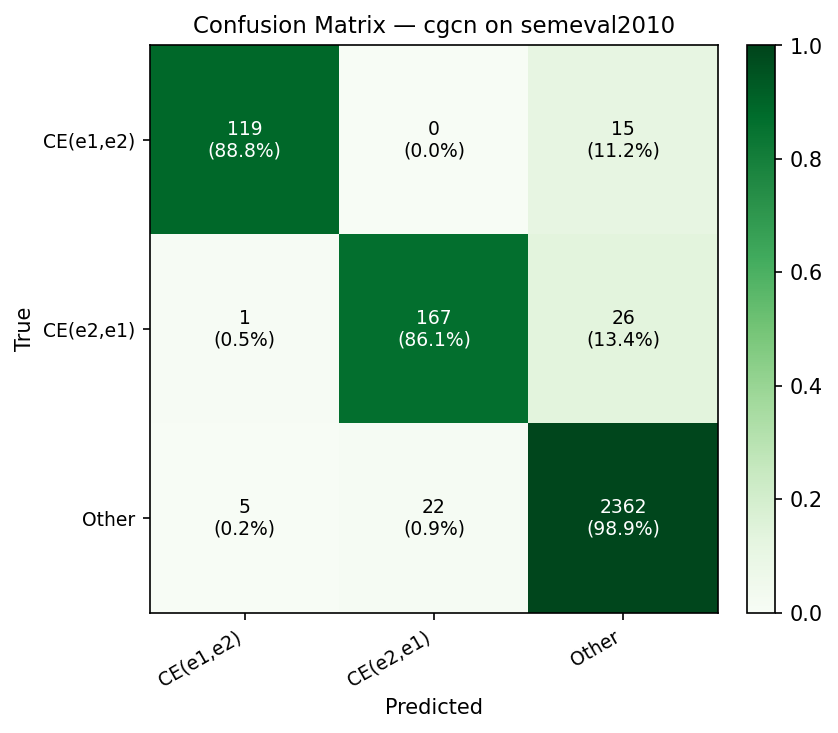

In [ ]:
from IPython.display import Image
Image('results/cgcn/semeval2010/confusion_matrix.png')